# Supplementary Material for Lecture 3: Binomial MLE

## Contents
- [S3.1 Problem setup](#section-s31)
  Define the observed binomial sample and summarize it by $k$ successes out of $n$ trials
- [S3.2 Analytical MLE](#section-s32)
  Differentiate the log-likelihood and solve for the maximizer
- [S3.3 Numerical MLE on a grid](#section-s33)
  Evaluate the likelihood over many candidate values of $\theta$
- [S3.4 Numerical MLE by optimization](#section-s34)
  Use `scipy.optimize` to maximize the log-likelihood directly
- [S3.5 Checks and edge cases](#section-s35)
  Compare methods and note what happens when the MLE lies on a boundary

This notebook is a short companion to Lecture 3. It shows the maximum-likelihood estimator (MLE) for a binomial model in two ways: first analytically, and then numerically.


## Setup


### Data access policy

This notebook is meant to run without requiring students to clone the full course repository.

This supplementary notebook uses synthetic Bernoulli/binomial data only, so there are no required external data files. The same search/download scaffold used in the lecture notebooks is still included below so the notebook stays consistent across Colab and local environments.


In [1]:
import importlib.util
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


print("Colab detected:", IS_COLAB)


Colab detected: False


### Required data files


In [2]:
REQUIRED_DATA_FILES = []


### Resolve required data files


In [3]:
from pathlib import Path
from urllib.parse import quote
import urllib.request

COURSE_REPO = "https://github.com/opherdonchin/StatisticsCourse_36714361"
DATA_BASE_URL = "https://raw.githubusercontent.com/opherdonchin/StatisticsCourse_36714361/main/Data"
SEARCH_DIRS = [
    Path("."),
    Path("data"),
    Path("Data"),
    Path("..") / "data",
    Path("..") / "Data",
]


def find_existing_file(filename):
    for directory in SEARCH_DIRS:
        candidate = (directory / filename).resolve()
        if candidate.exists():
            return candidate
    return None


def download_required_file(filename):
    destination = (Path(".") / filename).resolve()
    url = f"{DATA_BASE_URL}/{quote(filename)}"
    urllib.request.urlretrieve(url, destination)
    return destination


DATA_FILE_PATHS = {}
for filename in REQUIRED_DATA_FILES:
    existing_path = find_existing_file(filename)
    DATA_FILE_PATHS[filename] = existing_path if existing_path is not None else download_required_file(filename)

print("Resolved data files:", {name: str(path) for name, path in DATA_FILE_PATHS.items()})


def read_data_csv(filename, **kwargs):
    import pandas as pd

    return pd.read_csv(DATA_FILE_PATHS[filename], **kwargs)


Resolved data files: {}


## Imports


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import optimize, special

plt.rc("figure", dpi=150)
plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(suppress=True)


<a id="section-s31"></a>
## S3.1 Problem setup

Suppose we observe independent Bernoulli trials with common success probability $\theta$. If the sample contains $k$ successes out of $n$ trials, then the binomial likelihood is

$$
L(\theta \mid k, n) = \binom{n}{k} \theta^k (1-\theta)^{n-k}, \qquad 0 \le \theta \le 1.
$$

For the MLE we can work with the full sequence of 0/1 outcomes or just with the counts $k$ and $n$, because the binomial model depends on the sample only through those two numbers.


In [5]:
observed_data = np.array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0], dtype=int)
n = observed_data.size
k = int(observed_data.sum())
theta_hat_analytic = k / n

observed_sequence = "".join("H" if outcome else "T" for outcome in observed_data)
summary = pd.DataFrame(
    {
        "Quantity": ["Number of trials n", "Number of successes k", "Sample proportion k/n"],
        "Value": [n, k, theta_hat_analytic],
    }
)

print("Observed sequence:", observed_sequence)
display(summary)


Observed sequence: HHTHHHTHTHHHTHHTHHHT


,Quantity,Value
0,Number of trials n,20.0
1,Number of successes k,14.0
2,Sample proportion k/n,0.7


<a id="section-s32"></a>
## S3.2 Analytical MLE

Because the logarithm is monotone, maximizing the likelihood is equivalent to maximizing the log-likelihood:

$$
\ell(\theta) = \log L(\theta \mid k, n) = \log \binom{n}{k} + k \log(\theta) + (n-k) \log(1-\theta).
$$

The combinatorial term does not depend on $\theta$, so its derivative is zero. For an interior solution with $0 < \theta < 1$,

$$
\frac{d\ell}{d\theta} = \frac{k}{\theta} - \frac{n-k}{1-\theta}.
$$

Set the derivative equal to zero and solve:

$$
\frac{k}{\theta} = \frac{n-k}{1-\theta}
\qquad \Longrightarrow \qquad
k(1-\theta) = (n-k)\theta
\qquad \Longrightarrow \qquad
k = n\theta
\qquad \Longrightarrow \qquad
\hat{\theta}_{\mathrm{MLE}} = \frac{k}{n}.
$$

The second derivative is

$$
\frac{d^2 \ell}{d\theta^2} = -\frac{k}{\theta^2} - \frac{n-k}{(1-\theta)^2},
$$

which is strictly negative for $0 < \theta < 1$, so this critical point is indeed a maximum. The only special cases are $k=0$ and $k=n$, where the MLE lands on the boundary at $0$ or $1$.


In [6]:
second_derivative_at_mle = -(k / theta_hat_analytic**2) - ((n - k) / (1 - theta_hat_analytic) ** 2)

print(f"Analytic MLE: {theta_hat_analytic:.3f}")
print(f"Second derivative at the MLE: {second_derivative_at_mle:.3f}")


Analytic MLE: 0.700
Second derivative at the MLE: -95.238


<a id="section-s33"></a>
## S3.3 Numerical MLE on a grid

A direct numerical approach is to evaluate the likelihood on a dense grid of candidate $\theta$ values and keep the best one. In practice, it is usually better to work with the log-likelihood because it is numerically more stable.


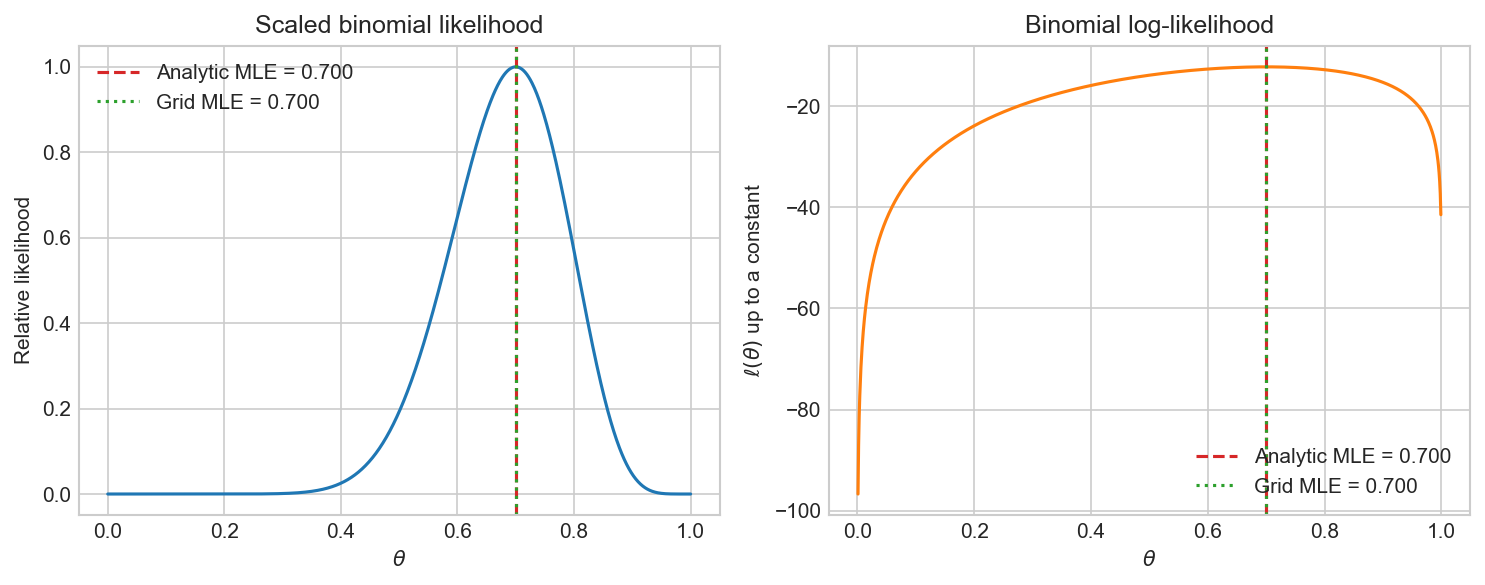

Grid-search MLE: 0.700


In [7]:
def binomial_loglikelihood(theta, k, n):
    theta = np.asarray(theta, dtype=float)
    return special.xlogy(k, theta) + special.xlog1py(n - k, -theta)


theta_grid = np.linspace(0.0, 1.0, 1001)
loglik_grid = binomial_loglikelihood(theta_grid, k, n)
scaled_likelihood = np.exp(loglik_grid - np.max(loglik_grid))
theta_hat_grid = float(theta_grid[np.argmax(loglik_grid)])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(theta_grid, scaled_likelihood, color="C0")
axes[0].axvline(theta_hat_analytic, color="C3", linestyle="--", label=f"Analytic MLE = {theta_hat_analytic:.3f}")
axes[0].axvline(theta_hat_grid, color="C2", linestyle=":", label=f"Grid MLE = {theta_hat_grid:.3f}")
axes[0].set_title("Scaled binomial likelihood")
axes[0].set_xlabel(r"$\theta$")
axes[0].set_ylabel("Relative likelihood")
axes[0].legend()

axes[1].plot(theta_grid, loglik_grid, color="C1")
axes[1].axvline(theta_hat_analytic, color="C3", linestyle="--", label=f"Analytic MLE = {theta_hat_analytic:.3f}")
axes[1].axvline(theta_hat_grid, color="C2", linestyle=":", label=f"Grid MLE = {theta_hat_grid:.3f}")
axes[1].set_title("Binomial log-likelihood")
axes[1].set_xlabel(r"$\theta$")
axes[1].set_ylabel(r"$\ell(\theta)$ up to a constant")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Grid-search MLE: {theta_hat_grid:.3f}")


<a id="section-s34"></a>
## S3.4 Numerical MLE by optimization

Grid search is easy to understand, but it becomes inefficient when a model has many parameters. A standard alternative is numerical optimization: maximize the log-likelihood directly, or equivalently minimize the negative log-likelihood.


In [8]:
def analytic_binomial_mle(k, n):
    return k / n


def optimize_binomial_mle(k, n):
    if k == 0:
        return {"theta_hat": 0.0, "status": "boundary maximum at 0", "nfev": 0}
    if k == n:
        return {"theta_hat": 1.0, "status": "boundary maximum at 1", "nfev": 0}

    result = optimize.minimize_scalar(
        lambda theta: -binomial_loglikelihood(theta, k, n),
        bounds=(0.0, 1.0),
        method="bounded",
    )
    return {"theta_hat": float(result.x), "status": result.message, "nfev": result.nfev}


optimization_result = optimize_binomial_mle(k, n)
theta_hat_optimized = optimization_result["theta_hat"]

comparison = pd.DataFrame(
    {
        "Method": ["Analytic", "Grid search", "Optimization"],
        "Estimate": [theta_hat_analytic, theta_hat_grid, theta_hat_optimized],
    }
)
comparison["Absolute difference from k/n"] = np.abs(comparison["Estimate"] - theta_hat_analytic)

display(comparison)
print("Optimization status:", optimization_result["status"])
print("Function evaluations:", optimization_result["nfev"])


,Method,Estimate,Absolute difference from k/n
0,Analytic,0.7,0.000000e+00
1,Grid search,0.7,1.110223e-16
2,Optimization,0.7,3.717369e-07


Optimization status: Solution found.
Function evaluations: 9


<a id="section-s35"></a>
## S3.5 Checks and edge cases

For ordinary interior cases, all three routes give the same answer up to numerical precision. The only subtlety is at the boundaries. If every trial is a failure, the likelihood is largest at $\theta = 0$; if every trial is a success, it is largest at $\theta = 1$. Those are still valid MLEs, even though the derivative-based interior argument no longer applies.


In [9]:
edge_case_records = []
for k_case in [0, 4, k, n]:
    theta_analytic_case = analytic_binomial_mle(k_case, n)
    loglik_case = binomial_loglikelihood(theta_grid, k_case, n)
    theta_grid_case = float(theta_grid[np.argmax(loglik_case)])
    theta_opt_case = optimize_binomial_mle(k_case, n)["theta_hat"]
    edge_case_records.append(
        {
            "k": k_case,
            "n": n,
            "Analytic": theta_analytic_case,
            "Grid search": theta_grid_case,
            "Optimization": theta_opt_case,
        }
    )

edge_case_table = pd.DataFrame(edge_case_records)
display(edge_case_table)


,k,n,Analytic,Grid search,Optimization
0,0,20,0.0,0.0,0.000000
1,4,20,0.2,0.2,0.200001
2,14,20,0.7,0.7,0.700000
3,20,20,1.0,1.0,1.000000


## Takeaway

For a binomial likelihood, the MLE is especially simple: it is just the observed proportion of successes, $\hat{\theta}_{\mathrm{MLE}} = k/n$. The numerical methods recover the same answer and illustrate the general strategy we use when an analytic derivation is no longer available.
